# Chapter 10 - Regularization

In the previous chapter, we learned that a model can fail in two common ways.
A very simple model can underfit, while a very complex model can overfit by learning noise from the training data.

Regularization helps us control this problem. It adds a penalty to the model training process so that the model learns useful patterns without depending too much on large, unstable weights.

In this chapter, we will study three regularized linear models:

- Ridge Regression, also called L2 regularization
- Lasso Regression, also called L1 regularization
- Elastic Net, which combines L1 and L2 regularization


## What Regularization Does

A linear model learns one coefficient, or weight, for each input feature. If a few weights become very large, the model can become too sensitive to small changes in the data.

Regularization changes the training objective. The model still tries to reduce prediction error, but it also gets penalized for using unnecessarily large weights.

This gives us a practical way to control model complexity without completely changing the model family.


## Step 1 - Import the required Libraries

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlxtend.evaluate import bias_variance_decomp
from sklearn.datasets import load_diabetes
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


## Step 2 - load the dataset

We will use the Diabetes dataset from scikit-learn.

In [59]:
# load diabetes dataset
data = load_diabetes()
X, y = data.data, data.target

# convert into DataFrame for clarity
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

print("First 5 rows of the dataset:")
print(df.head())

print("\nNumber of rows and columns:")
print(df.shape)

print("\nFeature names:")
print(data.feature_names)

First 5 rows of the dataset:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Number of rows and columns:
(442, 11)

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


Our data contains 442 rows and 10 numeric medical features. 

The target is a quantitative measure of diabetes progression one year after baseline.

## Step 3 - Prepare Train And Test Data

We split the data into training and testing parts. The training data is used for learning model coefficients. The test data is used only for checking how well the model generalizes.


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)


Training feature shape: (353, 10)
Testing feature shape: (89, 10)


### Before Scaling

Regularization penalizes coefficients. 

If features are not on a comparable scale, the penalty can become unfair. So before scaling, we inspect a small sample of the raw training data.


In [61]:
raw_train_preview = pd.DataFrame(X_train, columns=data.feature_names)
print("Raw training values before scaling:")
print(raw_train_preview.head())


Raw training values before scaling:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.070769  0.050680  0.012117  0.056301  0.034206  0.049416 -0.039719   
1 -0.009147  0.050680 -0.018062 -0.033213 -0.020832  0.012152 -0.072854   
2  0.005383 -0.044642  0.049840  0.097615 -0.015328 -0.016345 -0.006584   
3 -0.027310 -0.044642 -0.035307 -0.029770 -0.056607 -0.058620  0.030232   
4 -0.023677 -0.044642 -0.065486 -0.081413 -0.038720 -0.053610  0.059685   

         s4        s5        s6  
0  0.034309  0.027364 -0.001078  
1  0.071210  0.000272  0.019633  
2 -0.002592  0.017036 -0.013504  
3 -0.039493 -0.049872 -0.129483  
4 -0.076395 -0.037129 -0.042499  


### Apply Standard Scaling

`StandardScaler` standardizes each feature using the training data. After scaling, the features are easier to compare because they are centered around a common scale.


In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_train_preview = pd.DataFrame(X_train_scaled, columns=data.feature_names)
print("Scaled training values after StandardScaler:")
print(scaled_train_preview.head())

print("\nMean of scaled training columns, rounded:")
print(np.round(X_train_scaled.mean(axis=0), 3))


Scaled training values after StandardScaler:
        age       sex       bmi        bp        s1        s2        s3  \
0  1.498365  1.061370  0.219902  1.138874  0.728473  1.055893 -0.824451   
1 -0.228858  1.061370 -0.419366 -0.710591 -0.424929  0.272425 -1.529791   
2  0.085182 -0.942179  1.018987  1.992473 -0.309589 -0.326699 -0.119111   
3 -0.621409 -0.942179 -0.784662 -0.639458 -1.174640 -1.215508  0.664600   
4 -0.542899 -0.942179 -1.423930 -1.706457 -0.799784 -1.110167  1.291569   

         s4        s5        s6  
0  0.711038  0.547482 -0.061449  
1  1.484286 -0.019757  0.367236  
2 -0.062210  0.331237 -0.318660  
3 -0.835458 -1.069682 -2.719299  
4 -1.608706 -0.802859 -0.918820  

Mean of scaled training columns, rounded:
[ 0.  0. -0.  0. -0. -0.  0.  0.  0. -0.]


The before and after output shows the transformation clearly. 

The values have changed scale, but the rows and columns still represent the same observations and features.


## Step 4 - Ridge Regression

Ridge Regression adds an L2 penalty. This means it penalizes the squared values of the model coefficients.

The main effect is coefficient shrinkage. Ridge reduces large weights, but it normally does not make them exactly zero.


### Train A Linear Regression Baseline

First we train ordinary Linear Regression. This gives us a baseline test error before regularization.


In [63]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)
mse_linear = mean_squared_error(y_test, y_pred_linear)

print("Vanilla Linear Regression (Scaled Features)")
print(f"MSE: {mse_linear:.2f}")


Vanilla Linear Regression (Scaled Features)
MSE: 2900.19


This baseline model has no regularization penalty. Next we add Ridge and compare the test error.


### Train Ridge Regression

In scikit-learn, the regularization strength is controlled by `alpha`. A larger `alpha` means a stronger penalty.


In [64]:
ridge_model = Ridge(alpha=100)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("Ridge Regression (Scaled Features, alpha = 100)")
print(f"MSE: {mse_ridge:.2f}")


Ridge Regression (Scaled Features, alpha = 100)
MSE: 2858.22


In [65]:
print(f"MSE improvement compared with Linear Regression: {mse_linear - mse_ridge:.2f}")

MSE improvement compared with Linear Regression: 41.97


Ridge gives a lower test MSE on this split. This tells us that controlling coefficient size has helped the model generalize better.


### Compare Linear And Ridge Coefficients

To understand what Ridge changed, we compare the learned coefficients from both models.


In [66]:
weights_df = pd.DataFrame(
    {
        "Feature": data.feature_names,
        "Linear Regression Weights": linear_model.coef_,
        "Ridge Regression Weights": ridge_model.coef_,
    }
)

print(weights_df.to_string(index=False))


Feature  Linear Regression Weights  Ridge Regression Weights
    age                   1.753758                  2.093789
    sex                 -11.511809                 -8.168076
    bmi                  25.607121                 21.561936
     bp                  16.828872                 13.926917
     s1                 -44.448856                 -2.898262
     s2                  24.640954                 -4.087197
     s3                   7.676978                 -9.059339
     s4                  13.138784                  6.683867
     s5                  35.161195                 16.477222
     s6                   2.351364                  4.688816


Ridge has reduced the magnitude of many coefficients. 

For example, `s1`, `s2`, and `s5` are much less extreme in the Ridge model.

This is the regularization penalty doing its work.


## Step 5 - Study Ridge Coefficient Shrinkage

The chapter highlights three important Ridge ideas:

- Ridge shrinks coefficients.
- Larger coefficients are penalized more strongly.
- Ridge helps control the bias-variance tradeoff.


### Coefficients For Different Alpha Values

We now train Ridge models with increasing alpha values and plot the coefficients.


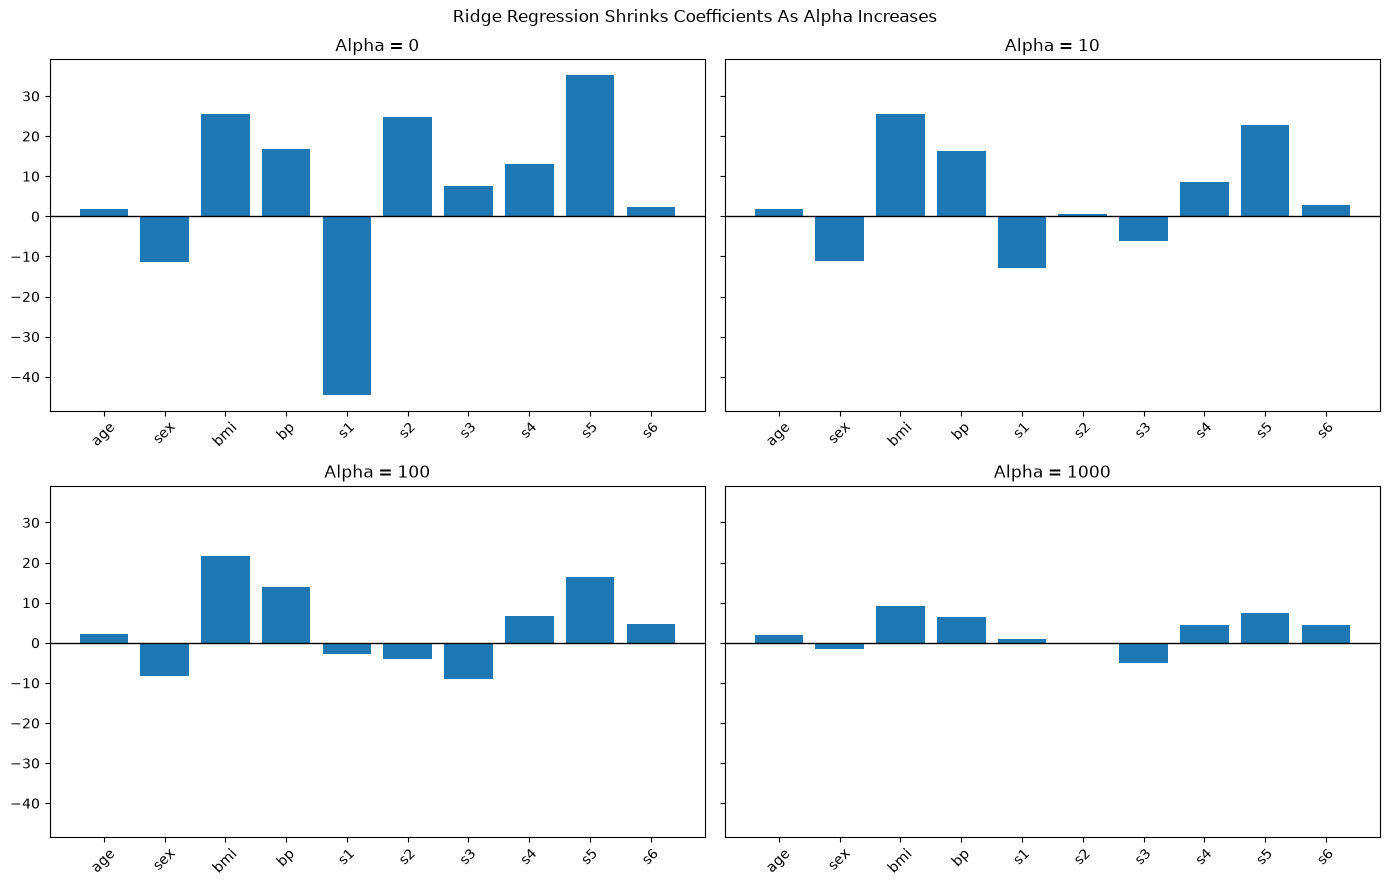

In [67]:
ridge_alphas = [0, 10, 100, 1000]
ridge_coefs = []

for alpha in ridge_alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    ridge_coefs.append(model.coef_)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.ravel()

for axis, alpha, coef in zip(axes, ridge_alphas, ridge_coefs):
    axis.bar(data.feature_names, coef)
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(f"Alpha = {alpha}")
    axis.tick_params(axis="x", rotation=45)

fig.suptitle("Ridge Regression Shrinks Coefficients As Alpha Increases")
fig.tight_layout()
plt.show()


At alpha 0, Ridge behaves like Linear Regression. 

As alpha increases, the coefficients move toward zero, but Ridge does not remove the features completely.


### Ridge Coefficient Paths

A coefficient path shows how each feature coefficient changes as alpha grows.


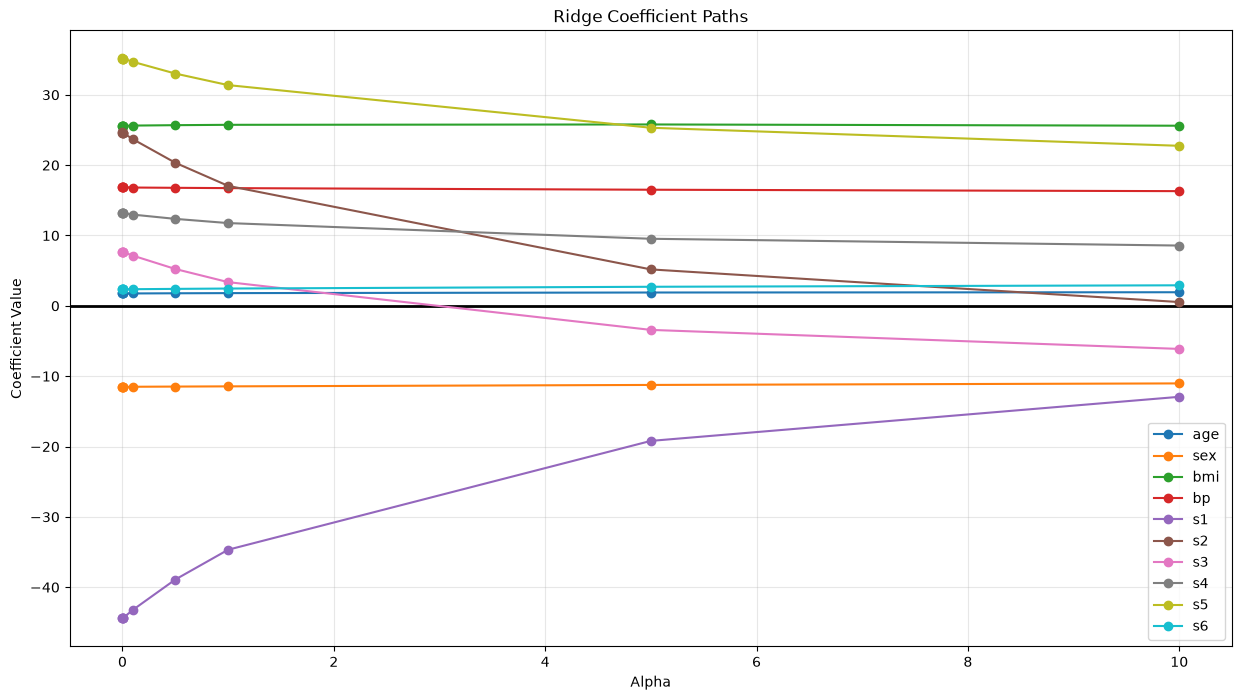

In [68]:
path_alphas = [0, 0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]
path_coefs = []

for alpha in path_alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    path_coefs.append(model.coef_)

path_array = np.array(path_coefs).T

plt.figure(figsize=(15, 8))
plt.axhline(0, color="black", linewidth=2)
for feature_index, feature_name in enumerate(data.feature_names):
    plt.plot(path_alphas, path_array[feature_index], marker="o", label=feature_name)

plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficient Paths")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


It is clear from the above figure that the large coefficients shrink strongly as alpha increases. 

This prevents one or two features from dominating the model too much.


### Ridge And Bias-Variance Tradeoff

Ridge can reduce variance because the model becomes less sensitive to noise. 

But if alpha becomes too large, bias can increase because the model becomes too simple.


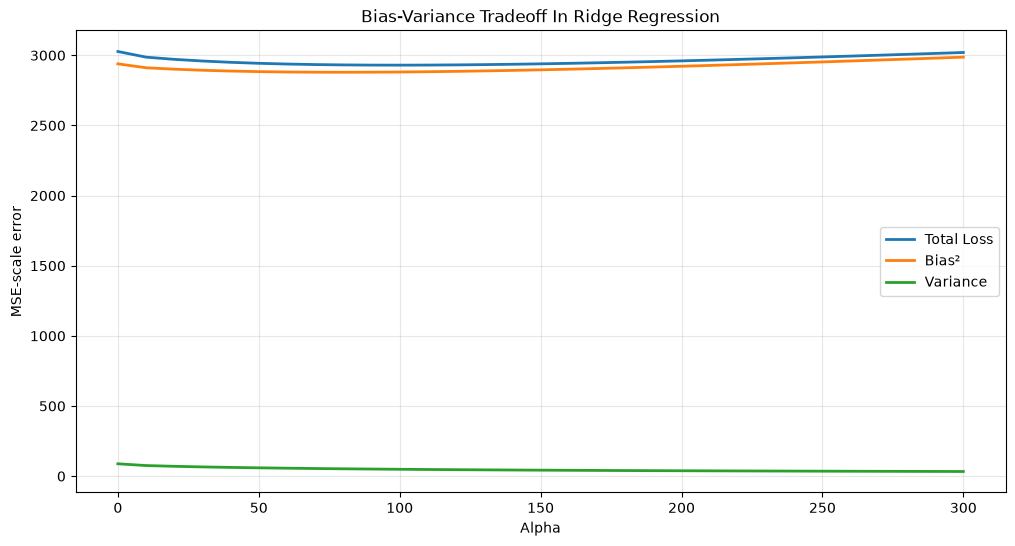

Lowest estimated loss in this tested range occurs near alpha = 100.00


In [69]:
bv_alphas = np.linspace(0, 300, 31)

loss_values = []
bias_squared_values = []
variance_values = []

for alpha in bv_alphas:
      model = Ridge(alpha=alpha)
      avg_loss, avg_bias_squared, avg_variance = bias_variance_decomp(
          model,
          X_train_scaled,
          y_train,
          X_test_scaled,
          y_test,
          loss="mse",
          random_seed=123,
          num_rounds=30,
      )

      loss_values.append(avg_loss)
      bias_squared_values.append(avg_bias_squared)
      variance_values.append(avg_variance)

plt.figure(figsize=(12, 6))
plt.plot(bv_alphas, loss_values, label="Total Loss", linewidth=2)
plt.plot(bv_alphas, bias_squared_values, label="Bias²", linewidth=2)
plt.plot(bv_alphas, variance_values, label="Variance", linewidth=2)

plt.xlabel("Alpha")
plt.ylabel("MSE-scale error")
plt.title("Bias-Variance Tradeoff In Ridge Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_index = int(np.argmin(loss_values))
print(
      "Lowest estimated loss in this tested range occurs near "
      f"alpha = {bv_alphas[best_index]:.2f}"
  )

  For `loss="mse"`, `bias_variance_decomp()` returns the squared bias term, so the plot label is `Bias²`, not raw `Bias`.

  The values are on the MSE scale. That is why Bias² can be around 2500-3000 while variance may be much smaller. 
  - For example, a typical prediction error of about 50 becomes 2500 after squaring.

  As alpha increases, variance usually decreases because Ridge makes the model more stable. 
  
  If alpha becomes too large, Bias² can increase because the model becomes too simple. 
  
  The best alpha is the lowest total loss within the tested alpha range.

## Step 6 - When To Use Ridge Regression

Ridge Regression is useful when many features may be important and we do not want to remove them from the model.

It is also useful when features are correlated with each other. In that case, ordinary Linear Regression coefficients can become unstable, while Ridge keeps them more controlled.


## Step 7 - Lasso Regression

Lasso Regression adds an L1 penalty. It penalizes the absolute values of the coefficients.

The special behavior of Lasso is that it can shrink some coefficients exactly to zero. This means Lasso can perform feature selection.


### Train Lasso On The Diabetes Dataset

We now use the same train-test split and scaled data to compare Lasso with the Linear Regression baseline.


In [70]:
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Lasso Regression MSE: {mse_lasso:.2f}")

Linear Regression MSE: 2900.19
Lasso Regression MSE: 2824.57


In [71]:
print(f"MSE improvement compared with Linear Regression: {mse_linear - mse_lasso:.2f}")

MSE improvement compared with Linear Regression: 75.63


On this split, Lasso improves the test MSE compared with ordinary Linear Regression.


### Lasso Coefficients For Different Alpha Values

Now we check how Lasso performs feature selection as alpha increases.


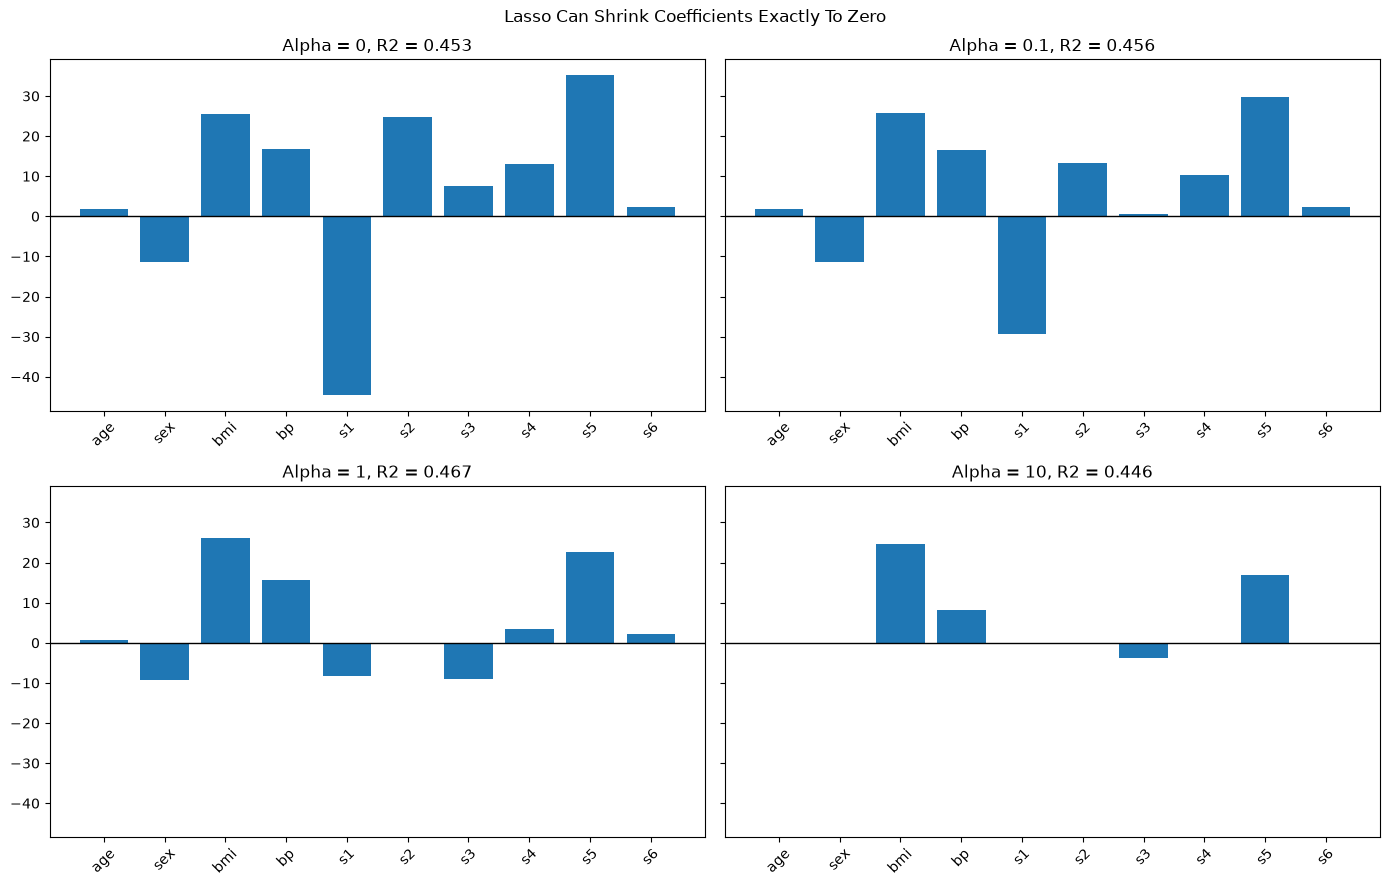

In [72]:
lasso_alphas = [0, 0.1, 1, 10]
lasso_coefs = []
lasso_r2_scores = []

for alpha in lasso_alphas:
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    lasso_coefs.append(model.coef_)
    lasso_r2_scores.append(r2_score(y_test, model.predict(X_test_scaled)))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.ravel()

for axis, alpha, coef, score in zip(axes, lasso_alphas, lasso_coefs, lasso_r2_scores):
    axis.bar(data.feature_names, coef)
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(f"Alpha = {alpha}, R2 = {score:.3f}")
    axis.tick_params(axis="x", rotation=45)

fig.suptitle("Lasso Can Shrink Coefficients Exactly To Zero")
fig.tight_layout()
plt.show()


In [73]:
lasso_summary = pd.DataFrame(
    np.array(lasso_coefs).T,
    index=data.feature_names,
    columns=[f"alpha={alpha}" for alpha in lasso_alphas],
)

print("Lasso coefficient summary:")
print(lasso_summary)


Lasso coefficient summary:
       alpha=0  alpha=0.1    alpha=1   alpha=10
age   1.753758   1.730451   0.687032   0.000000
sex -11.511809 -11.316359  -9.297519  -0.000000
bmi  25.607121  25.824627  26.219225  24.582549
bp   16.828872  16.644252  15.657314   8.114815
s1  -44.448856 -29.358412  -8.228172  -0.000000
s2   24.640954  13.275844  -0.000000  -0.000000
s3    7.676978   0.547948  -9.024087  -3.890621
s4   13.138784  10.236168   3.420861   0.000000
s5   35.161195  29.632826  22.636465  17.032649
s6    2.351364   2.393475   2.098647   0.000000


The above table makes it clear that
- At moderate alpha values, Lasso keeps only the stronger features. 
- At very high alpha values, it can remove too much information and underfit.


## Step 8 - When To Use Lasso Regression

Lasso is useful when we suspect only a few features are truly important.

It is also useful when interpretability matters, because zero coefficients make it easier to see which features the model has ignored.

If all features are important, Lasso may be too aggressive. In that case, Ridge may be safer.


## Compare Ridge And Lasso On Simple Linear Data

Now let's compares Ridge and Lasso using simple one-feature data. 
- Ridge usually flattens the line gradually. 
- Lasso can become more aggressive and remove the slope completely at high alpha values.


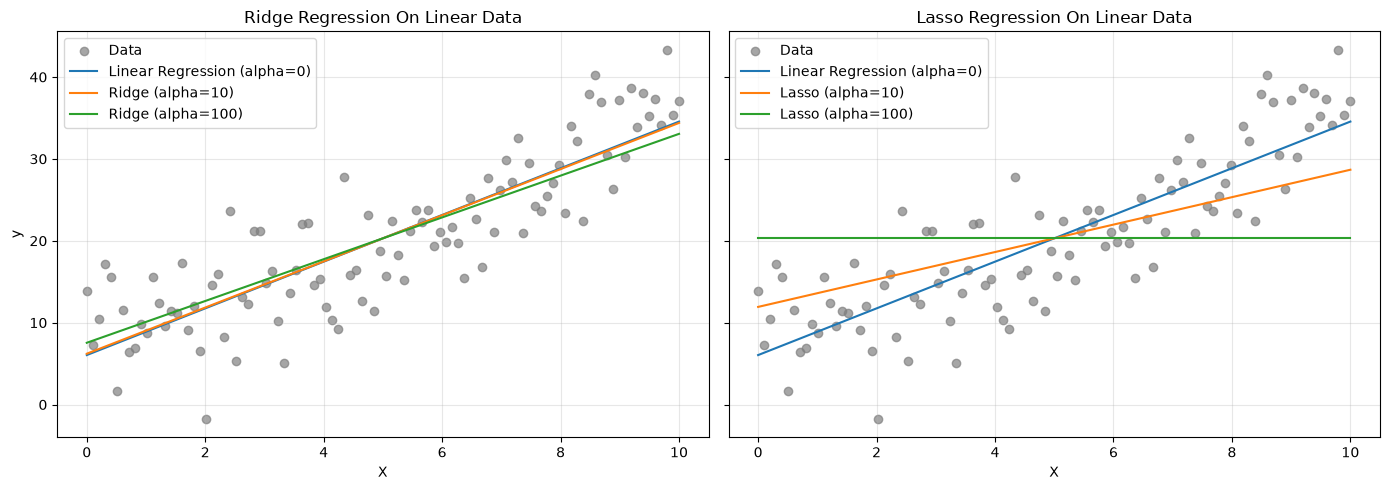

In [74]:
np.random.seed(0)
X_linear = np.linspace(0, 10, 100).reshape(-1, 1)
y_linear = 3 * X_linear.flatten() + 5 + np.random.randn(100) * 5
x_plot = np.linspace(0, 10, 100).reshape(-1, 1)
comparison_alphas = [0, 10, 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(X_linear, y_linear, color="gray", alpha=0.7, label="Data")
for alpha in comparison_alphas:
    model = LinearRegression() if alpha == 0 else Ridge(alpha=alpha)
    label = "Linear Regression (alpha=0)" if alpha == 0 else f"Ridge (alpha={alpha})"
    model.fit(X_linear, y_linear)
    axes[0].plot(x_plot, model.predict(x_plot), label=label)
axes[0].set_title("Ridge Regression On Linear Data")
axes[0].set_xlabel("X")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_linear, y_linear, color="gray", alpha=0.7, label="Data")
for alpha in comparison_alphas:
    model = LinearRegression() if alpha == 0 else Lasso(alpha=alpha, max_iter=10000)
    label = "Linear Regression (alpha=0)" if alpha == 0 else f"Lasso (alpha={alpha})"
    model.fit(X_linear, y_linear)
    axes[1].plot(x_plot, model.predict(x_plot), label=label)
axes[1].set_title("Lasso Regression On Linear Data")
axes[1].set_xlabel("X")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


Ridge keeps the feature active and reduces the slope gradually.

Lasso can make the line almost flat when the penalty is strong, meaning the feature has effectively been ignored.

## Step 9 - Elastic Net Regression

Elastic Net combines Ridge and Lasso.

- It can shrink coefficients like Ridge.
- It can set some coefficients to zero like Lasso.

In scikit-learn, `alpha` controls the total regularization strength and `l1_ratio` controls the mix between Lasso and Ridge.


### Train Elastic Net

We use `alpha = 1` and `l1_ratio = 0.9`. This makes the model behave closer to Lasso while still keeping some Ridge-style stability.


In [75]:
elastic_model = ElasticNet(alpha=1, l1_ratio=0.9, max_iter=10000)
elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_test_scaled)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)

print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Ridge Regression MSE: {mse_ridge:.2f}")
print(f"Lasso Regression MSE: {mse_lasso:.2f}")
print(f"Elastic Net MSE: {mse_elastic:.2f}")


Linear Regression MSE: 2900.19
Ridge Regression MSE: 2858.22
Lasso Regression MSE: 2824.57
Elastic Net MSE: 2822.31


In [76]:
model_comparison = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Ridge", "Lasso", "Elastic Net"],
        "MSE": [mse_linear, mse_ridge, mse_lasso, mse_elastic],
    }
).sort_values("MSE")

print("Model comparison sorted by test MSE:")
print(model_comparison.to_string(index=False))


Model comparison sorted by test MSE:
            Model         MSE
      Elastic Net 2822.309232
            Lasso 2824.568094
            Ridge 2858.224287
Linear Regression 2900.193628


Elastic Net gives a balanced option when we want both coefficient shrinkage and feature selection. It is especially useful when features are correlated or when we are unsure whether Ridge or Lasso is the better fit.


## Step 10 - When To Use Elastic Net

Elastic Net is useful when features are correlated, when the dataset has many features, or when we want a balance between Ridge stability and Lasso feature selection.

If the dataset is very small with only a few features, simple Linear Regression or Ridge may be easier to interpret.


## Chapter Recap

Regularization is a practical way to reduce overfitting by controlling model complexity.

- Ridge Regression uses an L2 penalty. It shrinks coefficients but usually keeps all features.
- Lasso Regression uses an L1 penalty. It can shrink some coefficients exactly to zero.
- Elastic Net combines L1 and L2 penalties, giving a flexible middle path.